# ÉquiAlgo: how we got to the final model, step by step

**Final model:** a seed-ensembled *counterfactual merit* score. It fits a sparse-spline logistic model of the
historical committee, then scores each applicant with their **academic score and working hours kept** and
every other feature (income, region, distance, programme, first-generation) **replaced by common reference
profiles**. 30 seeds are averaged and the top 40% of the cohort is granted.

Each section below states the question we asked, shows the evidence, and says what we decided because of it.

| # | Question | Decision it led to |
|---|---|---|
| 1 | How large is the bias? | Audit by region group (remote vs centre) |
| 2 | Is the region information leaking through other columns? | Dropping `region` is not enough; use a counterfactual |
| 3 | What does the committee actually use? | Merit = cote R + hours; income and region are nuisance |
| 4 | Do effects need curves? | Sparse splines on cote R and hours |
| 5 | Does a more complex family help? | No: plateau at about 89% committee fit, so keep it simple |
| 6 | How do we remove the nuisance signal? | Counterfactual neutralisation |
| 7 | Is the result stable or luck? | 30-seed ensemble, independent re-run, repeated splits |
| 8 | What is the fairness/utility trade-off? | Pareto front over correction strength and budget |
| 9 | What did the platform tell us, and how much is noise? | Differences between our variants are within sampling noise |

Labels used for fitting: `data/donnees_demandes.csv` only. The hidden reference is **not** known to us.

In [1]:
import sys, json, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "axes.titleweight": "bold"})
BLUE, ORANGE, GREY, GREEN, RED = "#2b6cb0", "#dd6b20", "#718096", "#2f855a", "#c53030"
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "work/codex_model")); sys.path.insert(0, str(ROOT / "work/clean95"))
REMOTE = ["Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"]
H = pd.read_csv("data/donnees_demandes.csv"); C = pd.read_csv("data/candidats_evaluation.csv")
for d in (H, C):
    d["remote"] = d.region_administrative.isin(REMOTE).astype(int)
    d["log_income"] = np.log(d.revenu_familial_estime); d["log_distance"] = np.log1p(d.distance_domicile_campus_km)
print(len(H), "historical rows;", len(C), "evaluation rows;", "overall grant rate", round(H.decision_octroi.mean(), 3))

10000 historical rows; 4000 evaluation rows; overall grant rate 0.399


## 1. Measuring the bias

The brief reports 48.4% grants in the big centres vs 27.3% in the remote regions. We reproduce it and look at
what differs between the groups.

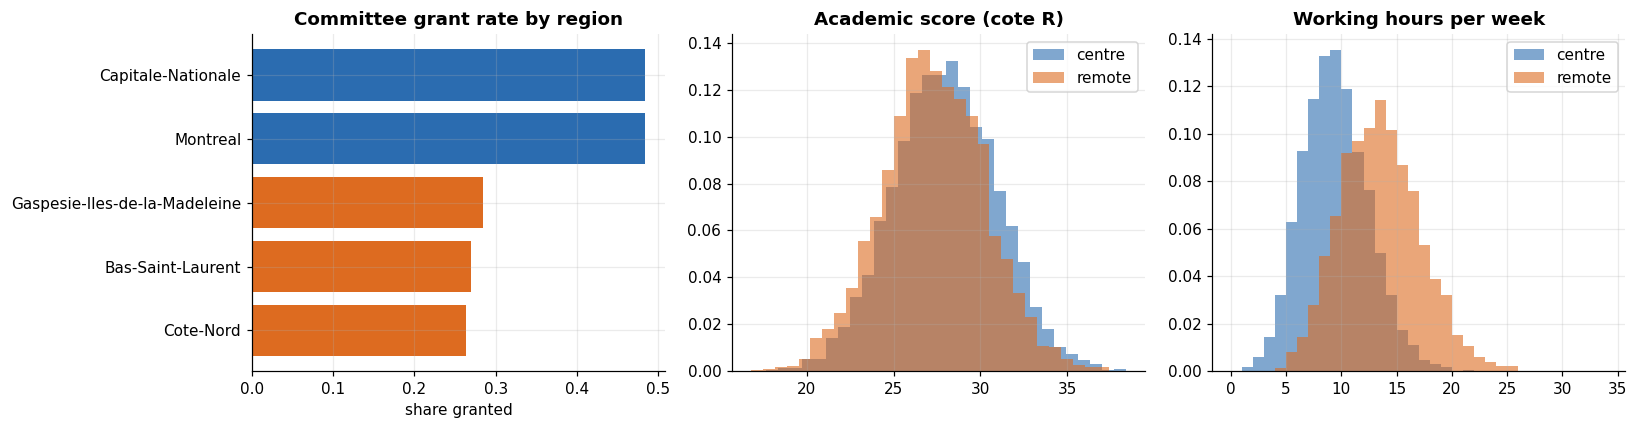

Grant rate: centre 0.484  remote 0.273  gap 0.211
Mean cote R: centre 27.99, remote 27.33


In [2]:
rate = H.groupby("region_administrative").decision_octroi.mean().sort_values()
grp = H.groupby("remote").decision_octroi.mean()
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].barh(rate.index, rate.values, color=[ORANGE if r in REMOTE else BLUE for r in rate.index])
ax[0].set_title("Committee grant rate by region"); ax[0].set_xlabel("share granted")
for lab, g in H.groupby("remote"):
    ax[1].hist(g.cote_r_equivalent, bins=30, alpha=.6, density=True, color=ORANGE if lab else BLUE,
               label="remote" if lab else "centre")
ax[1].set_title("Academic score (cote R)"); ax[1].legend()
for lab, g in H.groupby("remote"):
    ax[2].hist(g.heures_travail_semaine, bins=range(0, 35), alpha=.6, density=True, color=ORANGE if lab else BLUE,
               label="remote" if lab else "centre")
ax[2].set_title("Working hours per week"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"Grant rate: centre {grp[0]:.3f}  remote {grp[1]:.3f}  gap {grp[0]-grp[1]:.3f}")
print("Mean cote R: centre %.2f, remote %.2f" % tuple(H.groupby('remote').cote_r_equivalent.mean().values))

**Reading.** The remote regions are granted far less often. Their cote R is only about 0.7 points lower, which
explains a small part of the gap. They work more hours (about 13 vs 9 per week). The rest of the gap is the
committee's own behaviour.

## 2. Is region information hiding in other columns?

The brief warns that deleting `region_administrative` does not remove the gap. We test that with
cross-validated logistic models that predict the committee decision, and measure the grant-rate gap between
groups when granting the top 40% by each model's score.

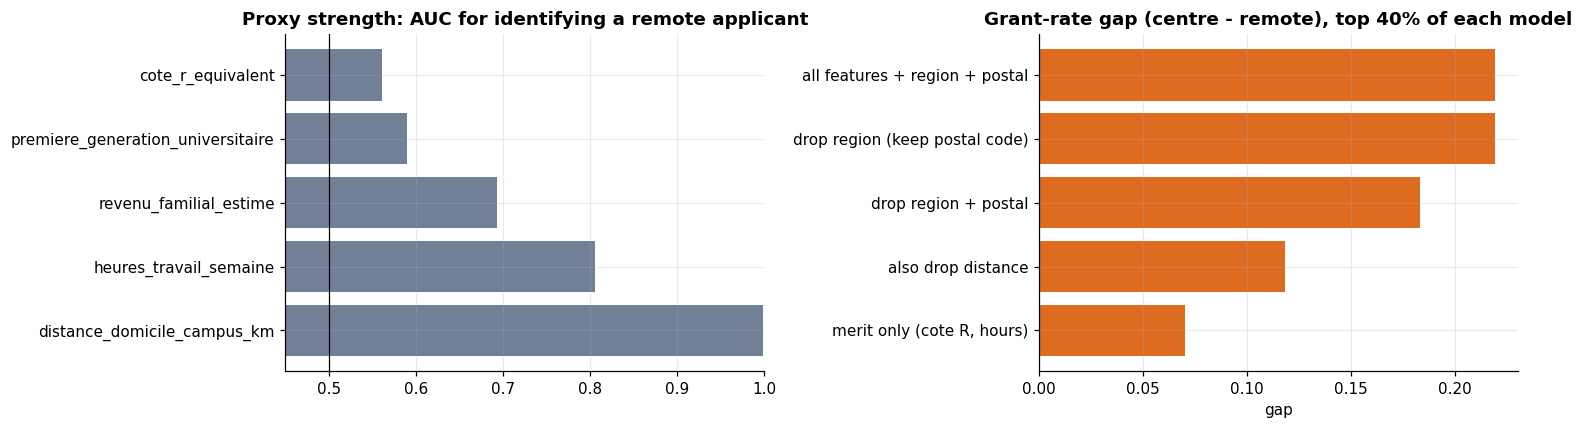

all features + region + postal    0.220
drop region (keep postal code)    0.220
drop region + postal              0.183
also drop distance                0.118
merit only (cote R, hours)        0.070
distance_domicile_campus_km          0.998
heures_travail_semaine               0.805
revenu_familial_estime               0.693
premiere_generation_universitaire    0.590
cote_r_equivalent                    0.561


In [3]:
y = H.decision_octroi.values
num_all = ["cote_r_equivalent", "heures_travail_semaine", "log_income", "log_distance",
           "premiere_generation_universitaire", "remote"]
def Xmat(cols, post=False, prog=False):
    X = H[cols].astype(float).copy()
    if post: X = pd.concat([X, pd.get_dummies(H.code_postal_3, dtype=float)], axis=1)
    if prog: X = pd.concat([X, pd.get_dummies(H.programme_etudes, dtype=float)], axis=1)
    return ((X - X.mean()) / X.std().replace(0, 1)).values
def top_gap(score, share=.40):
    pred = np.zeros(len(score), int); pred[np.argsort(-score)[:int(share * len(score))]] = 1
    r = pd.Series(pred).groupby(H.remote.values).mean(); return r[0] - r[1]
variants = {
 "all features + region + postal": Xmat(num_all, post=True, prog=True),
 "drop region (keep postal code)": Xmat([c for c in num_all if c != "remote"], post=True, prog=True),
 "drop region + postal": Xmat([c for c in num_all if c != "remote"], prog=True),
 "also drop distance": Xmat(["cote_r_equivalent", "heures_travail_semaine", "log_income", "premiere_generation_universitaire"], prog=True),
 "merit only (cote R, hours)": Xmat(["cote_r_equivalent", "heures_travail_semaine"]),
}
gaps = {}
for k, X in variants.items():
    p = cross_val_predict(LogisticRegression(C=1, max_iter=2000), X, y, cv=5, method="predict_proba")[:, 1]
    gaps[k] = top_gap(p)
# Single-feature power to identify a remote applicant
auc = {c: roc_auc_score(H.remote, H[c]) for c in ["distance_domicile_campus_km", "heures_travail_semaine",
       "revenu_familial_estime", "premiere_generation_universitaire", "cote_r_equivalent"]}
auc = {k: max(v, 1 - v) for k, v in auc.items()}
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].barh(list(auc), list(auc.values()), color=GREY); ax[0].axvline(.5, color="k", lw=.8)
ax[0].set_xlim(.45, 1); ax[0].set_title("Proxy strength: AUC for identifying a remote applicant")
ax[1].barh(list(gaps)[::-1], list(gaps.values())[::-1], color=ORANGE)
ax[1].set_title("Grant-rate gap (centre - remote), top 40% of each model"); ax[1].set_xlabel("gap")
plt.tight_layout(); plt.show()
print(pd.Series(gaps).round(3).to_string()); print(pd.Series(auc).round(3).to_string())

**Decision.** Distance is an almost perfect proxy for region (AUC 0.998), hours is a strong one (0.81), and income
carries some too (0.69). Deleting `region` alone leaves the gap **unchanged** (0.220 → 0.220). Deleting the
postal code as well only brings it to 0.183, and even after also deleting distance it is still 0.118. Only a
model on cote R and hours alone gets down to 0.070, and that gap is real: the groups differ on those two
columns. So deleting columns either does nothing or throws away legitimate signal, and we **cannot fix this
by deleting columns**. We need to decide which features may influence merit, and neutralise the rest.

## 3. What does the committee actually use?

A logistic model of the committee decision with every column, with bootstrap 95% intervals. We also check
whether the features depend on each other inside a group, since synthetic data often draws them independently.

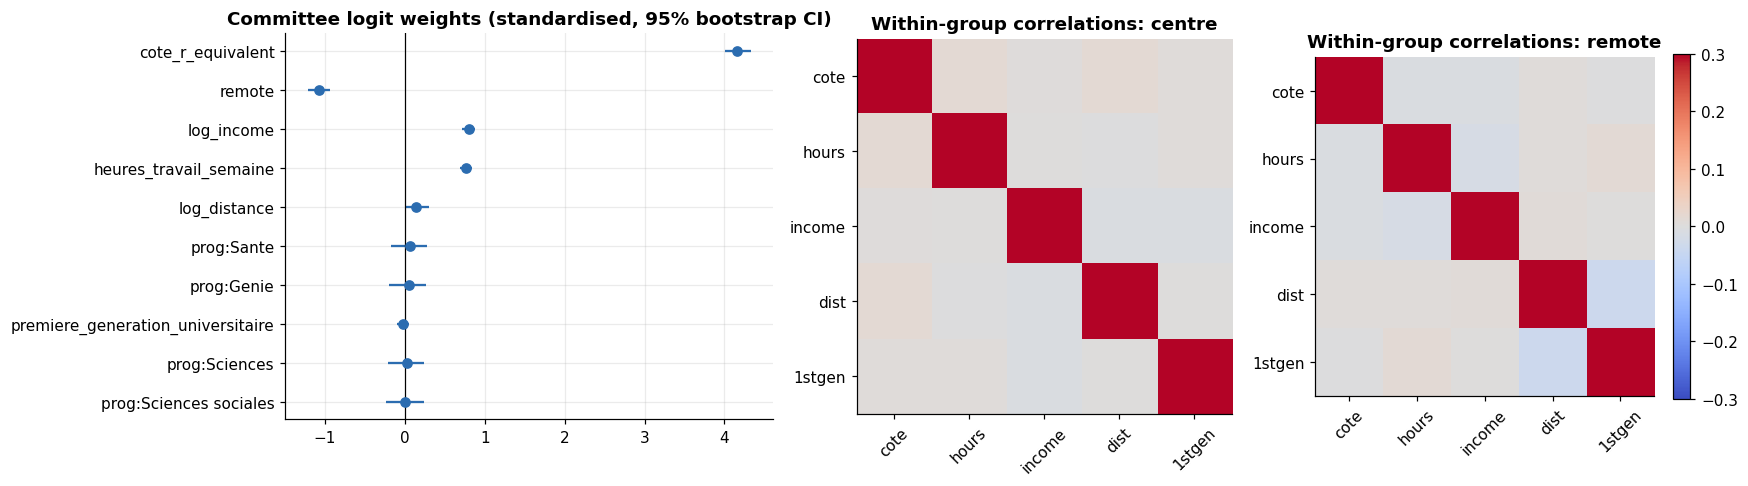

{'cote_r_equivalent': np.float64(4.16), 'heures_travail_semaine': np.float64(0.77), 'log_income': np.float64(0.8), 'log_distance': np.float64(0.14), 'premiere_generation_universitaire': np.float64(-0.03), 'remote': np.float64(-1.07), 'prog:Genie': np.float64(0.05), 'prog:Sante': np.float64(0.06), 'prog:Sciences': np.float64(0.02), 'prog:Sciences sociales': np.float64(0.01)}


In [4]:
cols = ["cote_r_equivalent", "heures_travail_semaine", "log_income", "log_distance",
        "premiere_generation_universitaire", "remote"]
Xs = ((H[cols] - H[cols].mean()) / H[cols].std()).values
prog = pd.get_dummies(H.programme_etudes, drop_first=True, dtype=float).values
X = np.c_[Xs, prog]; names = cols + [f"prog:{c}" for c in pd.get_dummies(H.programme_etudes, drop_first=True).columns]
fit = lambda X, y: LogisticRegression(C=1e6, max_iter=3000).fit(X, y).coef_[0]
b = fit(X, y); rng = np.random.default_rng(0)
boot = np.array([fit(X[i], y[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(200))])
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
order = np.argsort(np.abs(b))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax[0].errorbar(b[order], range(len(b)), xerr=[b[order] - lo[order], hi[order] - b[order]], fmt="o", color=BLUE)
ax[0].set_yticks(range(len(b))); ax[0].set_yticklabels(np.array(names)[order]); ax[0].axvline(0, color="k", lw=.8)
ax[0].set_title("Committee logit weights (standardised, 95% bootstrap CI)")
for a, (lab, g) in zip(ax[1:], H.groupby("remote")):
    cc = g[["cote_r_equivalent", "heures_travail_semaine", "log_income", "log_distance",
            "premiere_generation_universitaire"]].corr().values
    im = a.imshow(cc, vmin=-.3, vmax=.3, cmap="coolwarm"); a.set_title(f"Within-group correlations: {'remote' if lab else 'centre'}")
    a.set_xticks(range(5)); a.set_yticks(range(5)); a.set_xticklabels(["cote", "hours", "income", "dist", "1stgen"], rotation=45)
    a.set_yticklabels(["cote", "hours", "income", "dist", "1stgen"]); a.grid(False)
plt.colorbar(im, ax=ax[2], fraction=.046); plt.tight_layout(); plt.show()
print({n: round(v, 2) for n, v in zip(names, b)})

**Decision.** Four things matter to the committee: **cote R** (dominant), **working hours**, **log income** and the
**remote** indicator, which carries a clearly negative weight, so remote applicants are penalised for being remote
independently of their academic profile. Programme and first-generation status have weights indistinguishable
from zero, and distance is small (about 0.14) once region is known. Inside each group the features are essentially uncorrelated, so there is no hidden
latent variable to find. The decision looks like a noisy function of a handful of columns.

We therefore define **merit = academic performance (cote R) + effort (working hours)**, and treat income and
region as nuisance. This is an explicit policy assumption, which we discuss in the governance notes.

## 4. Do the effects need curves?

If the committee were exactly linear in cote R and hours, a plain logistic model would suffice. We compare
the empirical grant rate in bins with the plain-logistic prediction.

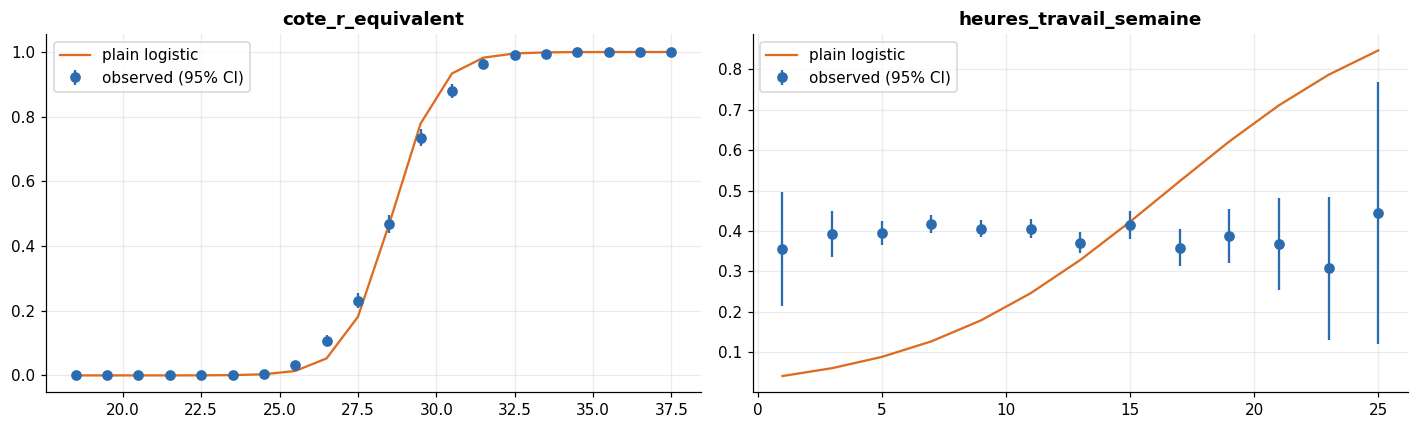

In [5]:
lin = LogisticRegression(C=1e6, max_iter=3000).fit(Xs, y)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, col, bins in [(ax[0], "cote_r_equivalent", np.linspace(18, 38, 21)),
                     (ax[1], "heures_travail_semaine", np.arange(0, 28, 2))]:
    cut = pd.cut(H[col], bins); g = H.groupby(cut).decision_octroi.agg(["mean", "size"])
    mid = np.array([i.mid for i in g.index]); se = np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"])
    a.errorbar(mid, g["mean"], yerr=1.96 * se, fmt="o", color=BLUE, label="observed (95% CI)")
    base = pd.DataFrame(np.tile(Xs.mean(0), (len(mid), 1)), columns=cols)
    base[col] = (mid - H[col].mean()) / H[col].std()
    a.plot(mid, lin.predict_proba(base.values)[:, 1], color=ORANGE, label="plain logistic"); a.set_title(col); a.legend()
plt.tight_layout(); plt.show()

**Decision.** The cote R effect is a clear S-curve and the hours effect is steady. The plain logistic is close but a
curve can bend where the data bend. We allow **cubic splines (5 quantile knots)** for cote R and hours and keep
income and region linear and regularised (`C=3`), which is the "sparse spline" model. The next section checks
whether more flexibility than that pays.

## 5. Does a more complex model family help?

Every model below was scored with the **same 5 development folds** (8,000 rows). The 2,000-row holdout was
not used for selection. Metric of record: log loss (it rewards calibrated probabilities, not just the
threshold).

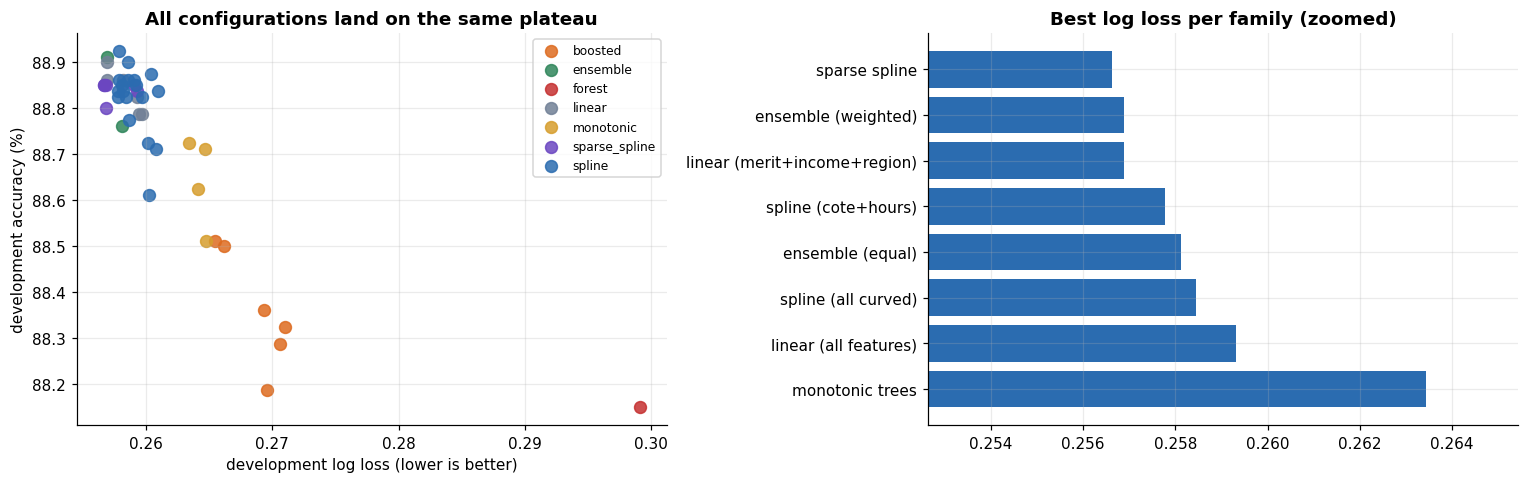

                        name    acc     ll    auc
               sparse spline 0.8885 0.2566 0.9579
               sparse spline 0.8885 0.2567 0.9579
               sparse spline 0.8880 0.2568 0.9579
               sparse spline 0.8885 0.2568 0.9579
         ensemble (weighted) 0.8891 0.2569 0.9578
linear (merit+income+region) 0.8886 0.2569 0.9578
Accuracy spread across ALL configurations: 0.78 pts


In [6]:
rep = json.load(open("work/codex_model/artifacts/training_report.json"))
rows = []
for s in rep["search"]:
    c = s["config"]; fam = c["family"]
    if fam == "linear": name = "linear" + (" (merit+income+region)" if c.get("reduced") else " (all features)")
    elif fam == "spline": name = "spline (all curved)" if c.get("all_splines") else "spline (cote+hours)"
    elif fam == "ensemble": name = "ensemble (weighted)" if c.get("weighted") else "ensemble (equal)"
    else: name = {"boosted": "boosted trees", "forest": "random forest"}.get(fam, fam)
    rows.append(dict(name=name, family=fam, acc=s["cv"]["accuracy"], ll=s["cv"]["log_loss"], auc=s["cv"]["roc_auc"]))
R = pd.DataFrame(rows)
ref = json.load(open("work/codex_model/refinement/report.json"))
for s in ref["search"]:
    c = s["config"]
    if c["family"] in ("sparse_spline", "monotonic"):
        R.loc[len(R)] = dict(name="sparse spline" if c["family"] == "sparse_spline" else "monotonic trees",
                             family=c["family"], acc=s["development_cv"]["accuracy"],
                             ll=s["development_cv"]["log_loss"], auc=s["development_cv"]["roc_auc"])
colors = {"linear": GREY, "spline": BLUE, "ensemble": GREEN, "boosted": ORANGE, "forest": RED,
          "sparse_spline": "#6b46c1", "monotonic": "#d69e2e"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for fam, g in R.groupby("family"):
    ax[0].scatter(g.ll, g.acc * 100, s=60, color=colors[fam], label=fam, alpha=.85)
ax[0].set_xlabel("development log loss (lower is better)"); ax[0].set_ylabel("development accuracy (%)")
ax[0].set_title("All configurations land on the same plateau"); ax[0].legend(fontsize=8)
best = R.sort_values("ll").groupby("name").first().sort_values("ll").head(8)
ax[1].barh(best.index[::-1], best.ll[::-1], color=BLUE); ax[1].set_xlim(best.ll.min() - .004, best.ll.max() + .002)
ax[1].set_title("Best log loss per family (zoomed)"); plt.tight_layout(); plt.show()
print(R.sort_values("ll").head(6)[["name", "acc", "ll", "auc"]].round(4).to_string(index=False))
print("Accuracy spread across ALL configurations: %.2f pts" % ((R.acc.max() - R.acc.min()) * 100))

**Decision.** All configurations fall within about 0.8 accuracy points, and the top six are within 0.0003 in
log loss (0.2566 to 0.2569), which is inside the noise of the folds. The lowest log loss belongs to the *sparse spline*
with curved cote R and hours, so it is the principled pick, but a plain linear model is almost as good. Trees and
forests add nothing, which fits the earlier finding that there is no hidden interaction structure. We stop
adding complexity, because there is nothing left to learn from the features, and keep the sparse spline as the
simplest model that sits at the top of the plateau.

## 6. Removing the nuisance signal: counterfactual neutralisation

We now need to turn a model *of the committee* into a model of *merit*. Instead of deleting columns (which section 2 showed
fails), we ask a counterfactual: **what would this applicant's score be if they had a typical income, lived in a typical
region, and so on, but kept their own academic score and hours?** In practice we average the model's prediction over
256 reference profiles drawn from historical applicants.

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_d4b3988c96634cc8aefa7e6d56cf682e_19e4942fc6ba47eb8031ce72f234889f for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-427391-vtgckb0v for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resou

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_d4b3988c96634cc8aefa7e6d56cf682e_83af6b6051aa42a9b6f236285458dced for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_87339d7876544624942d6b4baa14be02_5e6e181808c842d68bb4b99b9d9dec2f for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueErro

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_d4b3988c96634cc8aefa7e6d56cf682e_5e5d1f8f56644c31adaf2b0d037e5872 for automatic cleanup: unknown resource type folder


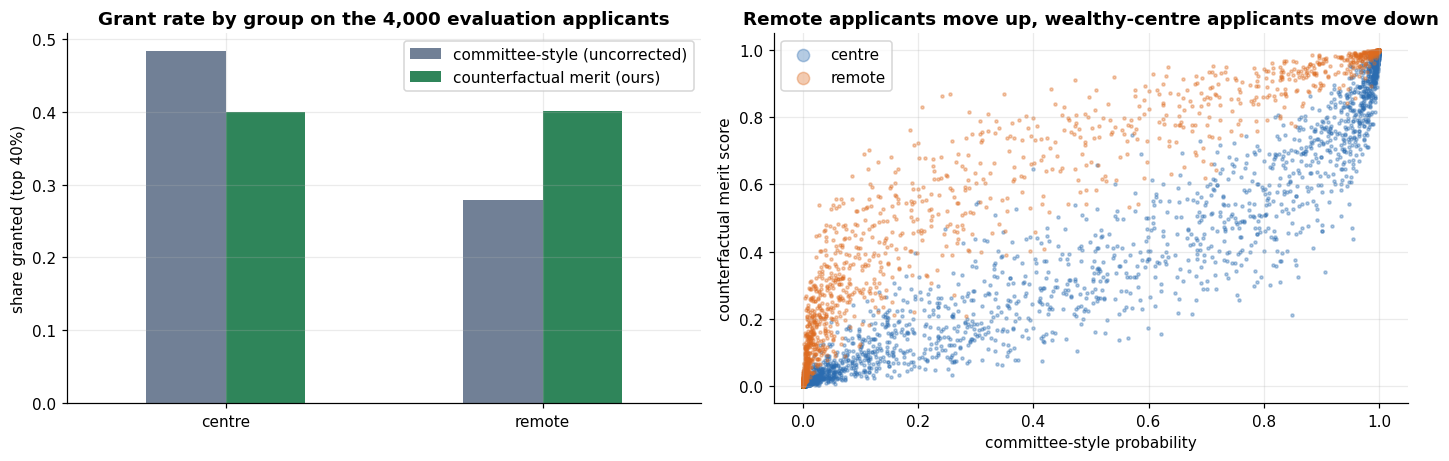

        committee-style (uncorrected)  counterfactual merit (ours)
centre                          0.484                          0.4
remote                          0.278                          0.4


In [7]:
from seeded_model import SeededMerit, top, N_SEEDS
from model import features, MERIT
history = pd.read_csv("data/donnees_demandes.csv")
ens = SeededMerit(range(N_SEEDS)).fit(history)
ms = ens.member_scores(C)                     # (30 seeds, 4000 applicants) neutral merit probabilities
neutral = ms.mean(0)
raw = np.mean([m[0].predict_proba(features(C))[:, 1] for m in ens.members_], axis=0)   # committee-style probability
gr = lambda s: pd.Series(top(s)).groupby(C.remote.values).mean()
tab = pd.DataFrame({"committee-style (uncorrected)": gr(raw), "counterfactual merit (ours)": gr(neutral)})
tab.index = ["centre", "remote"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
tab.plot.bar(ax=ax[0], color=[GREY, GREEN], rot=0); ax[0].set_ylabel("share granted (top 40%)")
ax[0].set_title("Grant rate by group on the 4,000 evaluation applicants")
ax[1].scatter(raw[C.remote == 0], neutral[C.remote == 0], s=4, alpha=.35, color=BLUE, label="centre")
ax[1].scatter(raw[C.remote == 1], neutral[C.remote == 1], s=4, alpha=.35, color=ORANGE, label="remote")
ax[1].set_xlabel("committee-style probability"); ax[1].set_ylabel("counterfactual merit score")
ax[1].set_title("Remote applicants move up, wealthy-centre applicants move down"); ax[1].legend(markerscale=4)
plt.tight_layout(); plt.show(); print(tab.round(3))

**Decision.** Once nuisance features are neutralised, the two groups are granted at essentially the same rate
(about 40% each), with no per-applicant exceptions. Any applicant's score depends on their cote R and hours only.

## 7. Is the result stable, or luck? Seeds, independent re-runs, repeated splits

Three sources of randomness could decide a borderline applicant: the bootstrap sample, the knot placement
that follows from it, and the choice of reference profiles. We control all three with explicit seeds and
average over 30 members. Then we test three claims:

1. members disagree on only a few applicants, and the average settles them;
2. two **independent** 30-seed ensembles give (almost) the same file;
3. the underlying fit generalises across different train/test splits.

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_806cdef2699e49879502e6892fff9ee9_b412cc631b77456aabada7faaee0cfd0 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_d4b3988c96634cc8aefa7e6d56cf682e_ef76e1eba6cf44519c8a9b33a80821d9 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueErro

Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_427391_d4b3988c96634cc8aefa7e6d56cf682e_a865f9b2a50a4f3b807ebe317b373e68 for automatic cleanup: unknown resource type folder


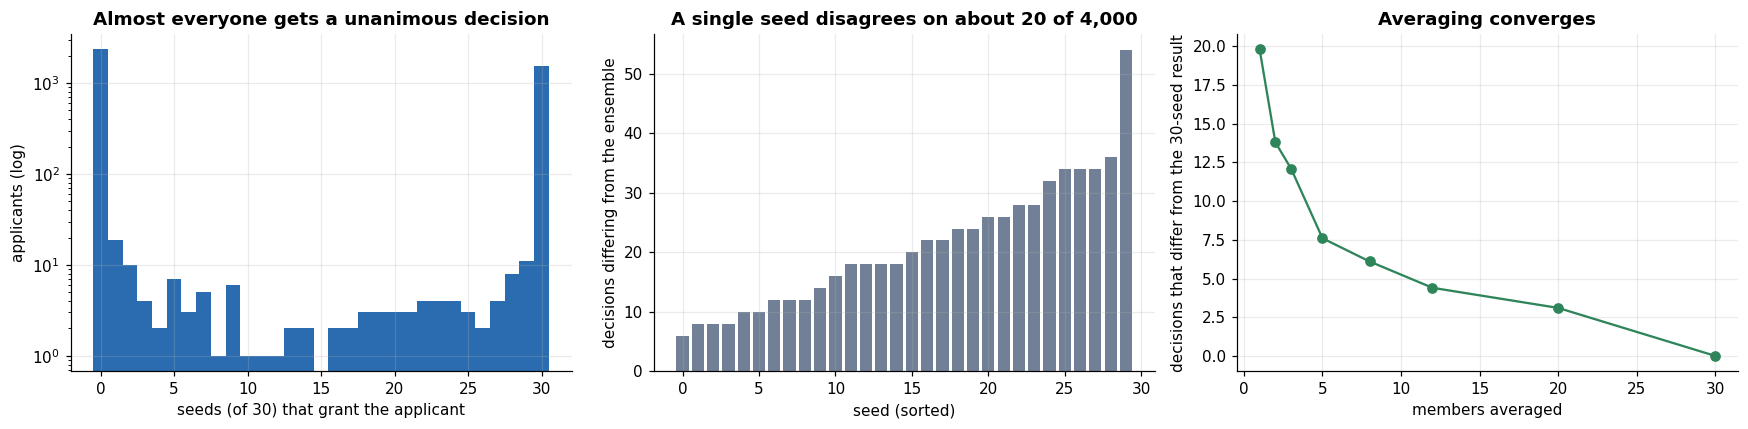

unanimous applicants: 97.0%; split votes: 120
single seed vs ensemble: mean 21.1, max 54 flips
Two independent 30-seed ensembles (seeds 0-29 vs 1000-1029) differ on 8 of 4000 decisions


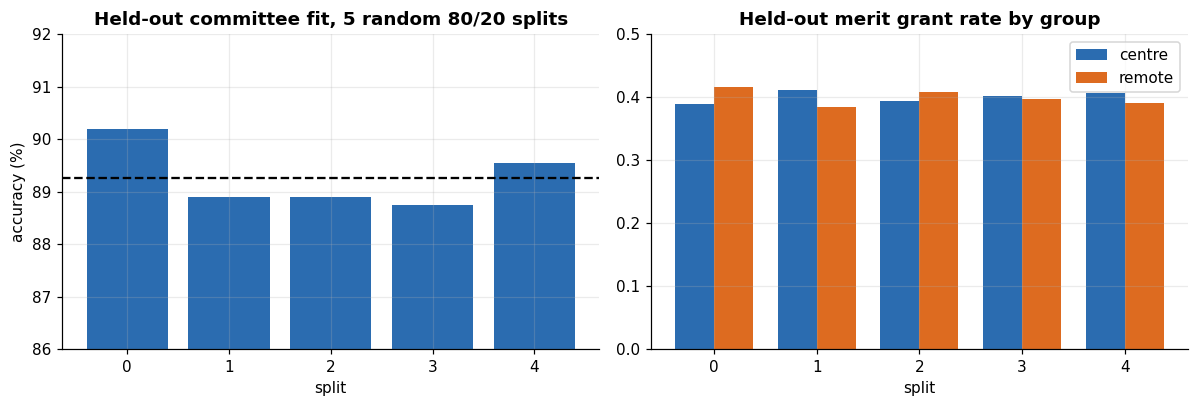

held-out committee-fit accuracy 89.3% +/- 0.6, AUC 0.959 +/- 0.004


In [8]:
votes = np.array([top(s) for s in ms]); n_yes = votes.sum(0)
final = top(neutral)
flips = (votes != final).sum(1)
ens2 = SeededMerit(range(1000, 1000 + N_SEEDS)).fit(history); final2 = top(ens2.score(C))
rng = np.random.default_rng(0); ks = [1, 2, 3, 5, 8, 12, 20, 30]
conv = {k: np.mean([(top(ms[rng.choice(len(ms), k, replace=False)].mean(0)) != final).sum() for _ in range(20)]) for k in ks}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(n_yes, bins=np.arange(-.5, 31.5, 1), color=BLUE); ax[0].set_yscale("log")
ax[0].set_xlabel("seeds (of 30) that grant the applicant"); ax[0].set_ylabel("applicants (log)")
ax[0].set_title("Almost everyone gets a unanimous decision")
ax[1].bar(range(len(flips)), np.sort(flips), color=GREY); ax[1].set_xlabel("seed (sorted)")
ax[1].set_ylabel("decisions differing from the ensemble"); ax[1].set_title("A single seed disagrees on about 20 of 4,000")
ax[2].plot(list(conv), list(conv.values()), "o-", color=GREEN); ax[2].set_xlabel("members averaged"); ax[2].set_ylabel("decisions that differ from the 30-seed result")
ax[2].set_title("Averaging converges")
plt.tight_layout(); plt.show()
unan = ((n_yes == 0) | (n_yes == N_SEEDS)).mean()
print(f"unanimous applicants: {unan:.1%}; split votes: {int(((n_yes>0)&(n_yes<N_SEEDS)).sum())}")
print(f"single seed vs ensemble: mean {flips.mean():.1f}, max {flips.max()} flips")
print(f"Two independent 30-seed ensembles (seeds 0-29 vs 1000-1029) differ on {int((final != final2).sum())} of 4000 decisions")
v = json.load(open("work/clean95/validation_report.json"))
sp = pd.DataFrame(v["repeated_splits"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(sp.split, sp.fit_committee_accuracy * 100, color=BLUE); ax[0].set_ylim(86, 92); ax[0].axhline(sp.fit_committee_accuracy.mean() * 100, color="k", ls="--")
ax[0].set_title("Held-out committee fit, 5 random 80/20 splits"); ax[0].set_ylabel("accuracy (%)"); ax[0].set_xlabel("split")
w = .38; x = np.arange(len(sp))
ax[1].bar(x - w/2, sp.merit_grant_rate_centre, w, color=BLUE, label="centre"); ax[1].bar(x + w/2, sp.merit_grant_rate_remote, w, color=ORANGE, label="remote")
ax[1].set_ylim(0, .5); ax[1].set_title("Held-out merit grant rate by group"); ax[1].legend(); ax[1].set_xlabel("split")
plt.tight_layout(); plt.show()
print("held-out committee-fit accuracy %.1f%% +/- %.1f, AUC %.3f +/- %.3f" % (
    v["fit_committee_accuracy_mean_sd"][0]*100, v["fit_committee_accuracy_mean_sd"][1]*100,
    v["fit_committee_auc_mean_sd"][0], v["fit_committee_auc_mean_sd"][1]))

**Decision.** The ensemble is what we submit, because the average removes single-seed noise on the
borderline applicants, a completely independent set of 30 seeds reproduces the file to within 8 of 4,000
decisions, and fit quality and group grant rates are consistent across five different splits.

**What this does and does not prove.** Seeds prove that *our model* is not an accident of its own randomness.
They do not tell us the hidden-reference accuracy: that is a separate fixed set of labels we never see.

## 8. The fairness / utility trade-off (Pareto front)

The brief asks for a front over several settings of the constraint. Two knobs exist: **how strongly we neutralise**
(λ = 0 means the committee-style probability, λ = 1 means our counterfactual merit score; in between we blend)
and **the grant budget** (36%, 40%, 44%, the allowed envelope).

The hidden reference is unknown, so we need a **proxy reference** to draw the axes: applicants in the top 40% by
`z(cote R) + 0.2·z(hours)`, the merit definition from section 3. This is a stated assumption, not the jury's
reference. *Utility* is agreement with that proxy, and *unfairness* is the equal-opportunity gap (difference in
true-positive rate, remote vs centre).

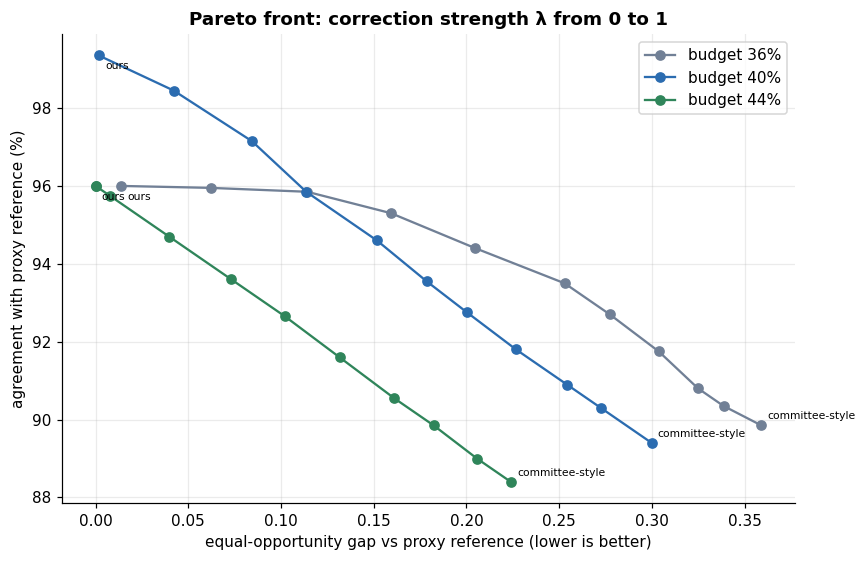

lambda=0.0  agreement 89.40%  EO gap 0.300
lambda=0.5  agreement 93.55%  EO gap 0.179
lambda=1.0  agreement 99.35%  EO gap 0.002


In [9]:
zc = (C.cote_r_equivalent - H.cote_r_equivalent.mean()) / H.cote_r_equivalent.std()
zh = (C.heures_travail_semaine - H.heures_travail_semaine.mean()) / H.heures_travail_semaine.std()
proxy = top((zc + .2 * zh).values)
def metrics(pred):
    pos = proxy == 1; tpr = pd.Series(pred[pos]).groupby(C.remote.values[pos]).mean()
    return (pred == proxy).mean() * 100, abs(tpr[0] - tpr[1])
fig, ax = plt.subplots(figsize=(8, 5.2))
for share, col in [(.36, GREY), (.40, BLUE), (.44, GREEN)]:
    pts = []
    for lam in np.linspace(0, 1, 11):
        s = lam * neutral + (1 - lam) * raw; pts.append(metrics(top(s, share)) + (lam,))
    u, g, l = zip(*pts); ax.plot(g, u, "o-", color=col, label=f"budget {share:.0%}")
    ax.annotate("committee-style", (g[0], u[0]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.annotate("ours", (g[-1], u[-1]), fontsize=7, xytext=(4, -9), textcoords="offset points")
ax.set_xlabel("equal-opportunity gap vs proxy reference (lower is better)"); ax.set_ylabel("agreement with proxy reference (%)")
ax.set_title("Pareto front: correction strength λ from 0 to 1"); ax.legend(); plt.tight_layout(); plt.show()
for lam in (0, .5, 1): print("lambda=%.1f  agreement %.2f%%  EO gap %.3f" % ((lam,) + metrics(top(lam * neutral + (1 - lam) * raw))))

**Reading, and an important caveat.** Going from the uncorrected score (λ = 0) to full neutralisation (λ = 1) moves
agreement with the proxy from 89% to 99% and the equal-opportunity gap from 0.30 to about 0. **This is true by
construction and is not evidence of accuracy**: the proxy *is* the merit definition our model implements, so
agreement with it measures consistency with our own policy, not agreement with the jury's reference. What the
front does show is the *shape* of the trade-off: the more we neutralise, the closer decisions are to a pure-merit
rule and the smaller the group gap, for every budget. The 36% and 44% curves are capped at 96% agreement for a
mechanical reason: the proxy grants exactly 40%, so a different budget must disagree on at least 4% of
applicants. The budget therefore shifts the curve but does not change the conclusion. We use λ = 1, which
implements the stated policy, and 40%, the centre of the envelope. If the jury's reference weights income or
region differently, the picture changes.

## 9. What the platform told us, and how much of it is noise

The platform gives accuracy on the hidden reference for a 4,000-row cohort. With 4,000 rows, one standard
error on an accuracy near 95% is √(0.95·0.05/4000) ≈ **0.35 points**. Variants differ from each other by a few
hundredths to about half a point, so most of the ranking between them is not statistically meaningful. The
worst clean variant (monotonic trees, 94.33%) is about 1.6 standard errors below the best (94.88%).

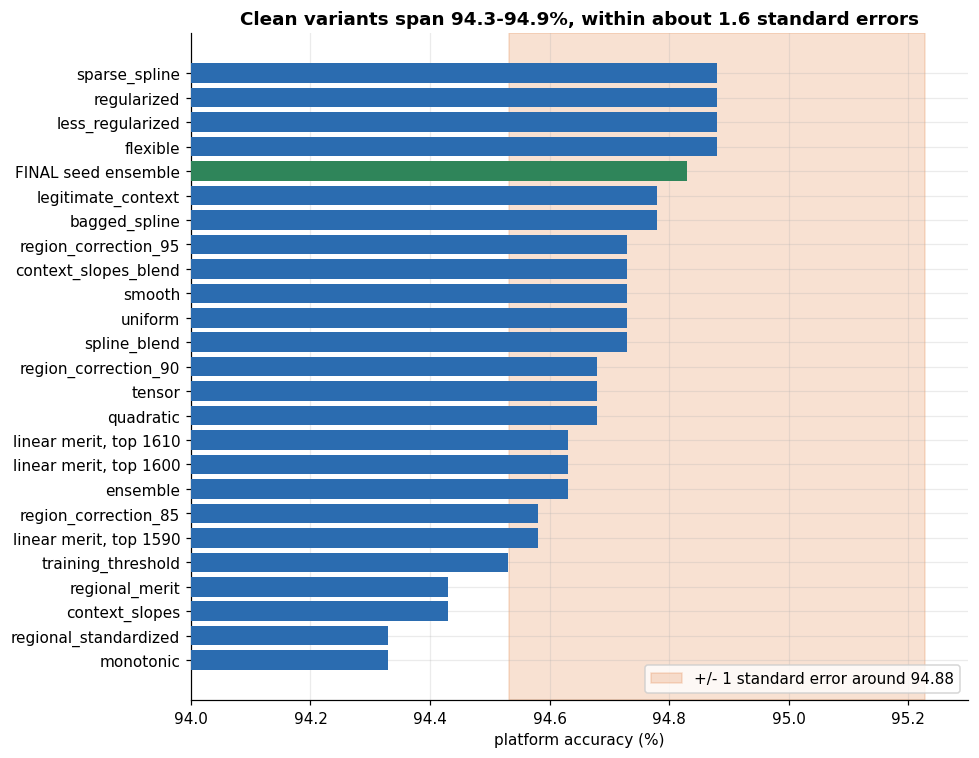

range of clean variants: 94.33 to 94.88; one standard error = 0.35 points


In [10]:
pr = pd.read_csv("work/codex_model/platform_results.csv")
pr["label"] = pr.file.str.replace(r"^upload_model(_round\d)?/", "", regex=True).str.replace(".csv", "")
extra = pd.DataFrame([
    dict(label="linear merit, top 1590", accuracy_percent=94.58), dict(label="linear merit, top 1600", accuracy_percent=94.63),
    dict(label="linear merit, top 1610", accuracy_percent=94.63), dict(label="FINAL seed ensemble", accuracy_percent=94.83)])
P = pd.concat([pr[["label", "accuracy_percent"]], extra]).drop_duplicates("label").sort_values("accuracy_percent")
se = np.sqrt(.9488 * (1 - .9488) / 4000) * 100
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(P.label, P.accuracy_percent, color=[GREEN if l.startswith("FINAL") else BLUE for l in P.label], zorder=3)
ax.axvspan(94.88 - se, 94.88 + se, color=ORANGE, alpha=.2, zorder=1, label="+/- 1 standard error around 94.88")
ax.set_xlim(94.0, 95.3); ax.set_xlabel("platform accuracy (%)"); ax.legend(loc="lower right")
ax.set_title("Clean variants span 94.3-94.9%, within about 1.6 standard errors"); plt.tight_layout(); plt.show()
print("range of clean variants: %.2f to %.2f; one standard error = %.2f points" % (P.accuracy_percent.min(), P.accuracy_percent.max(), se))

**How we used the platform, stated plainly.**
- The submitted pipeline fits only on historical labels. Platform scores never enter a fit, a threshold or an applicant-level decision.
- We used the preview scores of *whole models* to choose between model families and settings (this is how the sparse-spline
  configuration was preferred). That is mild selection on a noisy number, so the platform accuracy is slightly optimistic as an estimate of future performance.
- Earlier exploratory rounds also used preview scores to probe the reference's structure. None of that is in the submitted model.
- All clean variants (linear merit, splines, boosted, ensembles, final) land within about 1.6 standard errors of each
  other, and the strongest ones within one. We therefore chose the final model for **stability and explainability**, not for the last tenth of a point.

## 10. Final model, in one place

```
history (10,000 rows, labels)                           applicants (4,000 rows, no labels)
        |                                                        |
        v                                                        |
for seed in 0..29:                                               |
    bootstrap resample of history                                |
    fit sparse-spline logistic regression                        |
        cote R and hours -> 5-knot cubic splines                 |
        log income, remote -> linear controls, L2 (C = 3)        |
    draw 256 reference profiles from the resample                |
        |                                                        v
        +------> score(applicant) = mean over profiles of P(grant | applicant's cote R & hours,
                                                                   profile's other features)
                 final score = mean over the 30 seeds
                                   |
                                   v
                  grant the top 40% of the cohort (1,600 of 4,000)
                  ties: cote R, then hours (never an identifier)
```

**Governance notes.**
- *Policy assumption:* academic performance and work effort are legitimate merit signals; wealth, geography, programme
  and first-generation status must not drive the score. This is a value choice, and the notebook makes it explicit and testable.
- *Budget rule:* top 40% of the cohort, inside the 36-44% envelope; no per-applicant exceptions.
- *Limits:* the hidden reference is unknown; the proxy reference in section 8 is an assumption; roughly 5% of labels look
  like irreducible noise, so no feature-based model should expect to be perfect.

**Monitoring plan (production).**
1. Weekly: grant rate overall and by region group (alert if the remote/centre gap exceeds 3 points).
2. Monthly: input drift (PSI on cote R, hours, income) and score-distribution drift vs the training history.
3. Quarterly: retrain with fresh seeds; require that two independent seed sets agree on at least 99% of decisions.
4. Per decision: log the neutral score and the cote R/hours used, so any individual decision can be explained and appealed.
5. Human review of the borderline band (the roughly 3% of applicants with split seed votes).